<a href="https://colab.research.google.com/github/Marlon-Trujillo-Jaramillo/Biblio/blob/master/Interpolacion_Lagrange.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interpolación de Lagrange

El programa:
1. Pide la función $f(x)$ a aproximar, el grado $n$ y los $n+1$ nodos.
2. Construye el polinomio de Lagrange $P_n(x)=\sum_{i=0}^{n} f(x_i)\,L_i(x)$, con $L_i(x)=\prod_{j\ne i}\dfrac{x-x_j}{x_i-x_j}$.
3. Calcula la cota del error máximo en $[a,b]$:
$$|f(x)-P_n(x)|\le \frac{M}{(n+1)!}\max_{x\in[a,b]}\left|\prod_{i=0}^{n}(x-x_i)\right|,\qquad M=\max_{x\in[a,b]}|f^{(n+1)}(x)|$$
4. Evalúa $P_n$ en los puntos que quieras y da el error relativo $\dfrac{|f(x_0)-P_n(x_0)|}{|f(x_0)|}$.
5. Grafica $f$ y $P_n$ en el intervalo, junto con el error.

**Uso:** ejecuta la celda 1 (definiciones) y luego la celda 2. Escribe las funciones con sintaxis de Python/SymPy: `sin(x)`, `exp(x)`, `x**2`, `1/(1+25*x**2)`, `log(x)`, `sqrt(x)`. Los nodos aceptan expresiones como `pi/4`.

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x = sp.symbols('x')


def vectorizar(expr):
    """Convierte una expresión de sympy en una función de numpy (funciona aunque sea constante)."""
    g = sp.lambdify(x, expr, 'numpy')
    return lambda t: np.asarray(g(t), dtype=float) * np.ones_like(np.asarray(t, dtype=float))


def leer_datos():
    print("=== Interpolación de Lagrange ===")
    print("Puedes usar expresiones como: sin(x), exp(x)*cos(x), 1/(1+25*x**2), sqrt(x), log(x)")
    f = sp.sympify(input("Función a aproximar f(x) = "))

    n = int(input("Grado n del polinomio: "))
    print(f"Ingresa los {n + 1} nodos x_0 ... x_{n} (puedes escribir cosas como pi/4):")
    xs = [float(sp.N(sp.sympify(input(f"  x_{i} = ")))) for i in range(n + 1)]

    if len(set(xs)) != len(xs):
        raise ValueError("Los nodos deben ser distintos entre sí.")
    return f, xs


def polinomio_lagrange(xs, ys):
    """Devuelve el polinomio P(x) y la lista de polinomios base L_i(x)."""
    n = len(xs) - 1
    bases = []
    for i in range(n + 1):
        Li = sp.Integer(1)
        for j in range(n + 1):
            if j != i:
                Li *= (x - xs[j]) / (xs[i] - xs[j])
        bases.append(sp.expand(Li))
    P = sp.expand(sum(ys[i] * bases[i] for i in range(n + 1)))
    return P, bases


def cota_error(f, xs, a, b, puntos=20000):
    """
    Cota del error de Lagrange en [a, b]:
        |f(x) - P(x)| <= M / (n+1)! * max |w(x)|,
    con M = max |f^(n+1)(x)| y w(x) = (x - x_0)(x - x_1)...(x - x_n).
    """
    n = len(xs) - 1
    deriv = sp.diff(f, x, n + 1)
    w = sp.prod([(x - xi) for xi in xs])

    t = np.linspace(a, b, puntos)
    M = np.nanmax(np.abs(vectorizar(deriv)(t)))
    max_w = np.nanmax(np.abs(vectorizar(w)(t)))
    cota = M / sp.factorial(n + 1) * max_w
    return float(cota), float(M), deriv, w


def evaluar_en_punto(f, P, x0, M, w, n):
    fx0 = float(f.subs(x, x0).evalf())
    px0 = float(P.subs(x, x0).evalf())
    err_abs = abs(fx0 - px0)
    err_rel = err_abs / abs(fx0) if fx0 != 0 else float('nan')
    cota_x0 = M / float(sp.factorial(n + 1)) * abs(float(w.subs(x, x0)))
    return fx0, px0, err_abs, err_rel, cota_x0


def graficar(f, P, xs, a, b, puntos_eval=()):
    margen = 0.05 * (b - a) if b > a else 1
    t = np.linspace(a - margen, b + margen, 1000)
    ft, Pt = vectorizar(f)(t), vectorizar(P)(t)
    fx_nodos = vectorizar(f)(np.array(xs))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                                   gridspec_kw={'height_ratios': [3, 1.3]})
    ax1.plot(t, ft, label=f'f(x) = {sp.sstr(f)}', lw=2)
    ax1.plot(t, Pt, '--', label=f'P_{len(xs) - 1}(x) (Lagrange)', lw=2)
    ax1.plot(xs, fx_nodos, 'ko', label='Nodos')
    for x0 in puntos_eval:
        ax1.plot(x0, float(P.subs(x, x0)), 'r*', ms=14)
        ax1.annotate(f'  x={x0:g}', (x0, float(P.subs(x, x0))), color='red')
    ax1.axvspan(a, b, color='gray', alpha=0.08, label='Intervalo [a, b]')
    ax1.set_title('Comparación entre f(x) y el polinomio de Lagrange')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(t, np.abs(ft - Pt), color='purple')
    ax2.set_title('Error real |f(x) − P(x)|')
    ax2.set_xlabel('x'); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


def main():
    f, xs = leer_datos()
    n = len(xs) - 1
    ys = [float(f.subs(x, xi).evalf()) for xi in xs]
    a, b = min(xs), max(xs)

    print("\nTabla de datos:")
    for i, (xi, yi) in enumerate(zip(xs, ys)):
        print(f"  x_{i} = {xi:<12.6g} f(x_{i}) = {yi:.10g}")

    P, bases = polinomio_lagrange(xs, ys)
    print("\nPolinomios base L_i(x):")
    for i, Li in enumerate(bases):
        print(f"  L_{i}(x) = {sp.N(Li, 6)}")
    print(f"\nPolinomio de Lagrange de grado {n}:")
    print(f"  P_{n}(x) = {sp.N(P, 8)}")

    cota, M, deriv, w = cota_error(f, xs, a, b)
    t = np.linspace(a, b, 20000)
    err_real = np.nanmax(np.abs(vectorizar(f)(t) - vectorizar(P)(t)))
    print(f"\nError máximo en [{a:g}, {b:g}]:")
    print(f"  f^({n + 1})(x) = {sp.simplify(deriv)}")
    print(f"  M = max|f^({n + 1})(x)| ≈ {M:.6g}")
    print(f"  Cota teórica: |f(x) − P(x)| ≤ M/({n + 1})! · max|w(x)| ≈ {cota:.6e}")
    print(f"  Error real máximo (numérico)              ≈ {err_real:.6e}")

    evaluados = []
    while True:
        dato = input("\nPunto donde evaluar P(x) (Enter para terminar): ").strip()
        if not dato:
            break
        x0 = float(sp.N(sp.sympify(dato)))
        fx0, px0, ea, er, cx0 = evaluar_en_punto(f, P, x0, M, w, n)
        evaluados.append(x0)
        print(f"  f({x0:g})  = {fx0:.10g}")
        print(f"  P({x0:g})  = {px0:.10g}")
        print(f"  Error absoluto = {ea:.6e}")
        print(f"  Error relativo = {er:.6e}  ({er * 100:.6f} %)" if fx0 != 0
              else "  Error relativo: no definido porque f(x0) = 0")
        print(f"  Cota del error en ese punto ≈ {cx0:.6e}")
        if not (a <= x0 <= b):
            print("  ⚠ El punto está fuera del intervalo de los nodos (extrapolación): la cota máxima no aplica.")

    graficar(f, P, xs, a, b, evaluados)



## Ejecutar el programa

=== Interpolación de Lagrange ===
Puedes usar expresiones como: sin(x), exp(x)*cos(x), 1/(1+25*x**2), sqrt(x), log(x)
Función a aproximar f(x) = 1/(1+25*x**2)
Grado n del polinomio: 3
Ingresa los 4 nodos x_0 ... x_3 (puedes escribir cosas como pi/4):
  x_0 = pi/2
  x_1 = pi/3
  x_2 = pi/4
  x_3 = pi/6

Tabla de datos:
  x_0 = 1.5708       f(x_0) = 0.01595277277
  x_1 = 1.0472       f(x_1) = 0.03519197673
  x_2 = 0.785398     f(x_2) = 0.06089667846
  x_3 = 0.523599     f(x_3) = 0.1273254085

Polinomios base L_i(x):
  L_0(x) = 2.32211*x**3 - 5.47134*x**2 + 4.13803*x - 1.0
  L_1(x) = -13.9327*x**3 + 40.1232*x**2 - 34.3775*x + 9.0
  L_2(x) = 18.5769*x**3 - 58.361*x**2 + 56.0225*x - 16.0
  L_3(x) = -6.96633*x**3 + 23.7092*x**2 - 25.7831*x + 9.0

Polinomio de Lagrange de grado 3:
  P_3(x) = -0.20899432*x**3 + 0.78951815*x**2 - 1.0150553*x + 0.47235684

Error máximo en [0.523599, 1.5708]:
  f^(4)(x) = 15000*(10000*x**4 - 300*x**2*(25*x**2 + 1) + (25*x**2 + 1)**2)/(25*x**2 + 1)**5
  M = max|f^

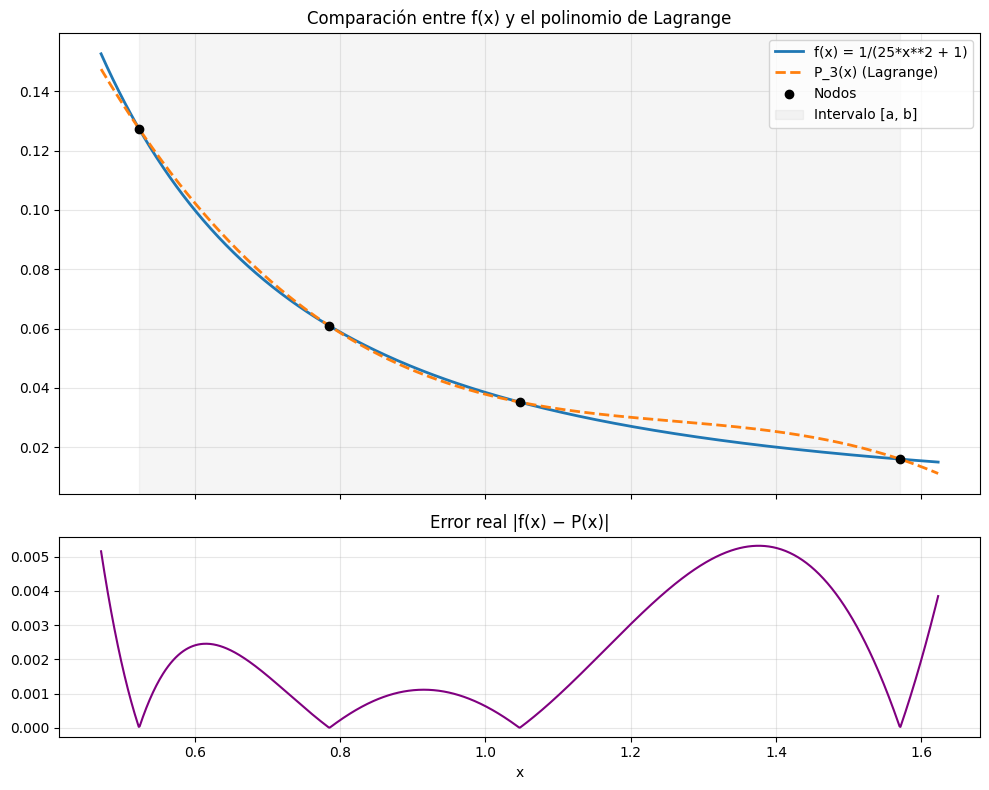

In [4]:
main()